In [1]:
import cogsworth
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns
import os

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
files = ["fiducial", "bhflag_0"]
labels = ["Fiducial", "BH Flag 0"]
colours = ["tab:blue", "tab:red"]

In [3]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

Loading post-processed data for Fiducial from fiducial
Loading post-processed data for BH Flag 0 from bhflag_0


In [4]:
companions = data["Fiducial"]["companion"]["BH"][(data["Fiducial"]["sep"]["BH"] > 0) & (data["Fiducial"]["primary"]["BH"])]
uni, count = np.unique(companions, return_counts=True)
uni, count

print("Number of BH + star:", count[uni < 10].sum())
print("Number of BH + WD:", count[(uni >= 10) & (uni <= 12)].sum())
print("Number of BH + NS:", count[uni == 13].sum())
print("Number of BH + BH:", count[uni == 14].sum())

Number of BH + star: 1917
Number of BH + WD: 13767
Number of BH + NS: 1318
Number of BH + BH: 69254


In [5]:
pop = pops[0]

In [6]:
scale_up = 6e10 / data["Fiducial"]["mass_binaries"]
scale_up

np.float64(95.86507214247818)

In [7]:
n_ns = len(data["Fiducial"]["mass"]["NS"])
n_bh = len(data["Fiducial"]["mass"]["BH"])
print(f"Rates (unscaled)\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
print(f"Rates (scaled)\n  Total: {(n_ns + n_bh) * scale_up:.1e}, NSs: {n_ns * scale_up:.1e}, BHs: {n_bh * scale_up:.1e}")

Rates (unscaled)
  Total: 7009448, NSs: 5202699, BHs: 1806749
Rates (scaled)
  Total: 6.7e+08, NSs: 5.0e+08, BHs: 1.7e+08


Olejak+20 predicted 1.2e8 BHs, close!

In [8]:
if os.path.exists("/mnt/ceph/users/twagg/underworld/stars_sfh.h5"):
    stars = cogsworth.sfh.load("/mnt/ceph/users/twagg/underworld/stars_sfh.h5")
else:
    stars = cogsworth.sfh.SandersBinney2015(
        **{
            "potential": gp.MilkyWayPotential(version='v2'),
            "time_bins": 5,
            "verbose": True,
            "include_bar": False,
        }
    )
    stars.sample(n_bh)
    stars.save("/mnt/ceph/users/twagg/underworld/stars_sfh")

# Old method

Fitting Black holes using model: exp_plus_sech2
  Optimal parameters: [1.63642749 0.43431353 1.07374519 2.56364634]
  Parameter errors: [ 3.29560412  7.32409306 12.67418638 14.38783128]
 Estimated scale height: 541.27 pc ± 14.39 pc
Fitting Stars using model: exp
  Optimal parameters: [3.20791391 3.22797286]
  Parameter errors: [17.33231035 24.66011864]
 Estimated scale height: 309.85 pc ± 24.66 pc


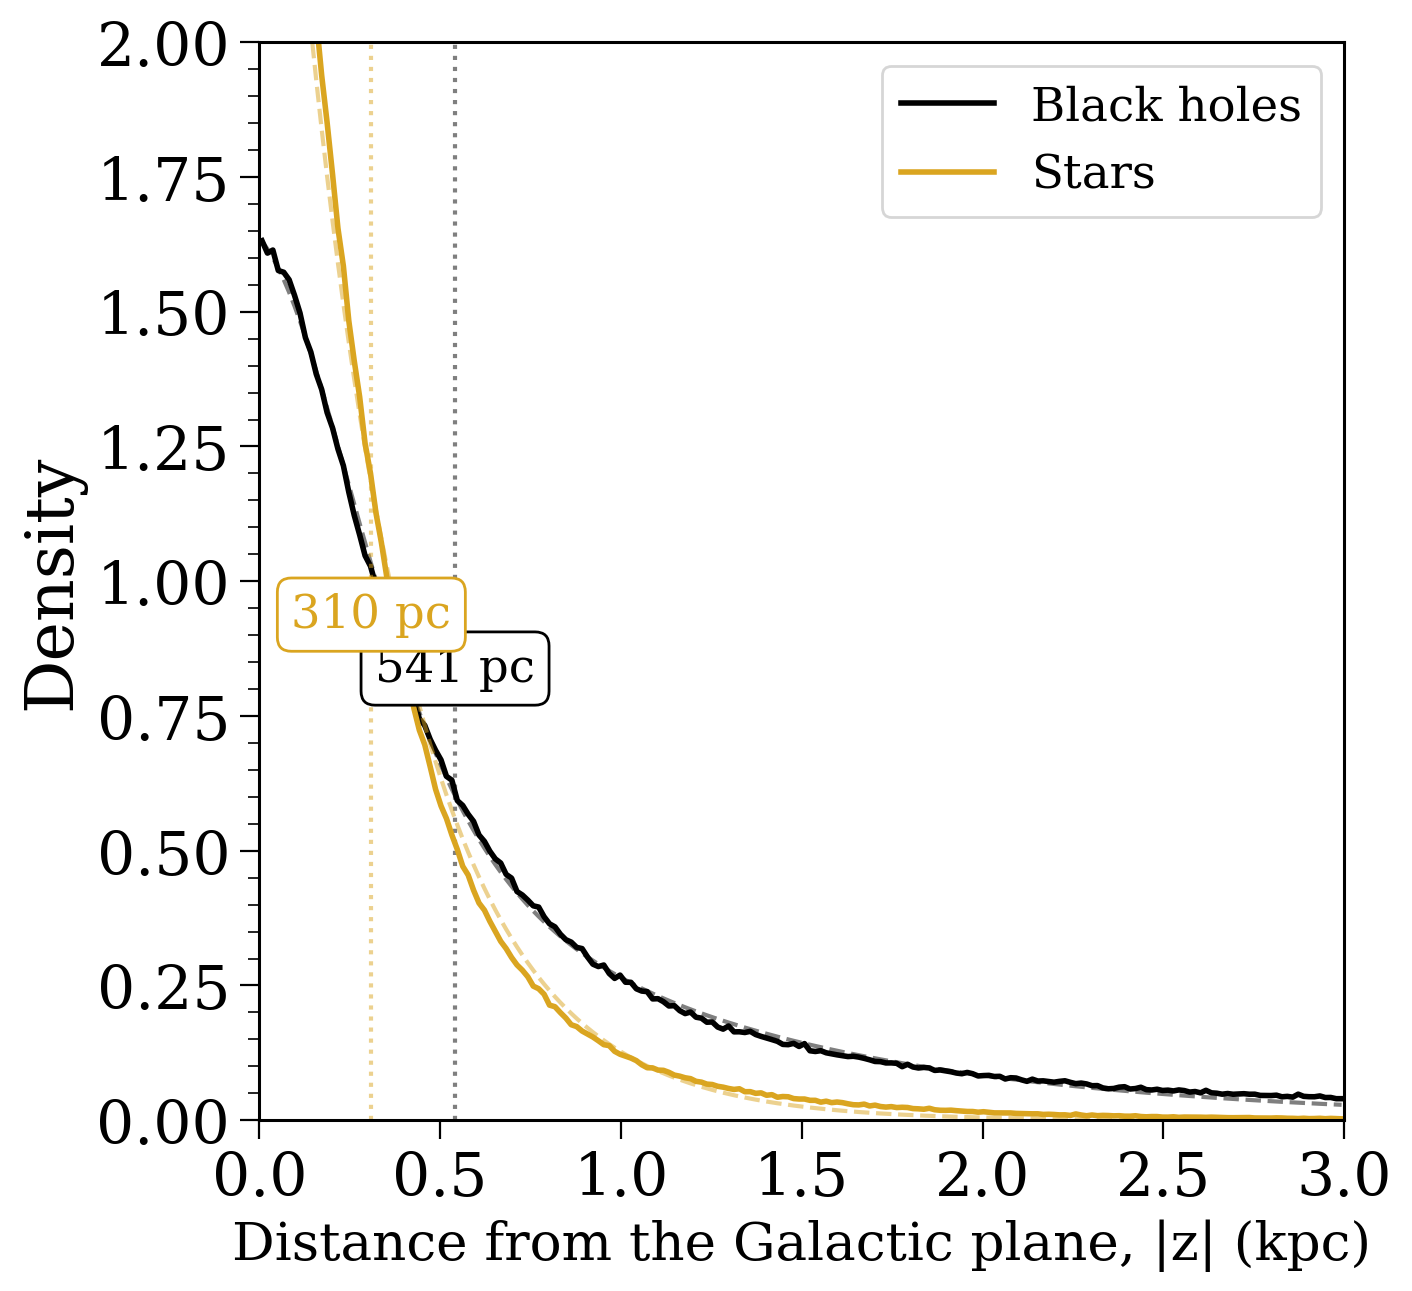

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]], stars.z],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(0, 3),
        ylim=(0, 2.0),
        model="exp_plus_sech2" if label != "Stars" else "exp",
        # yscale="log",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

# CDF method

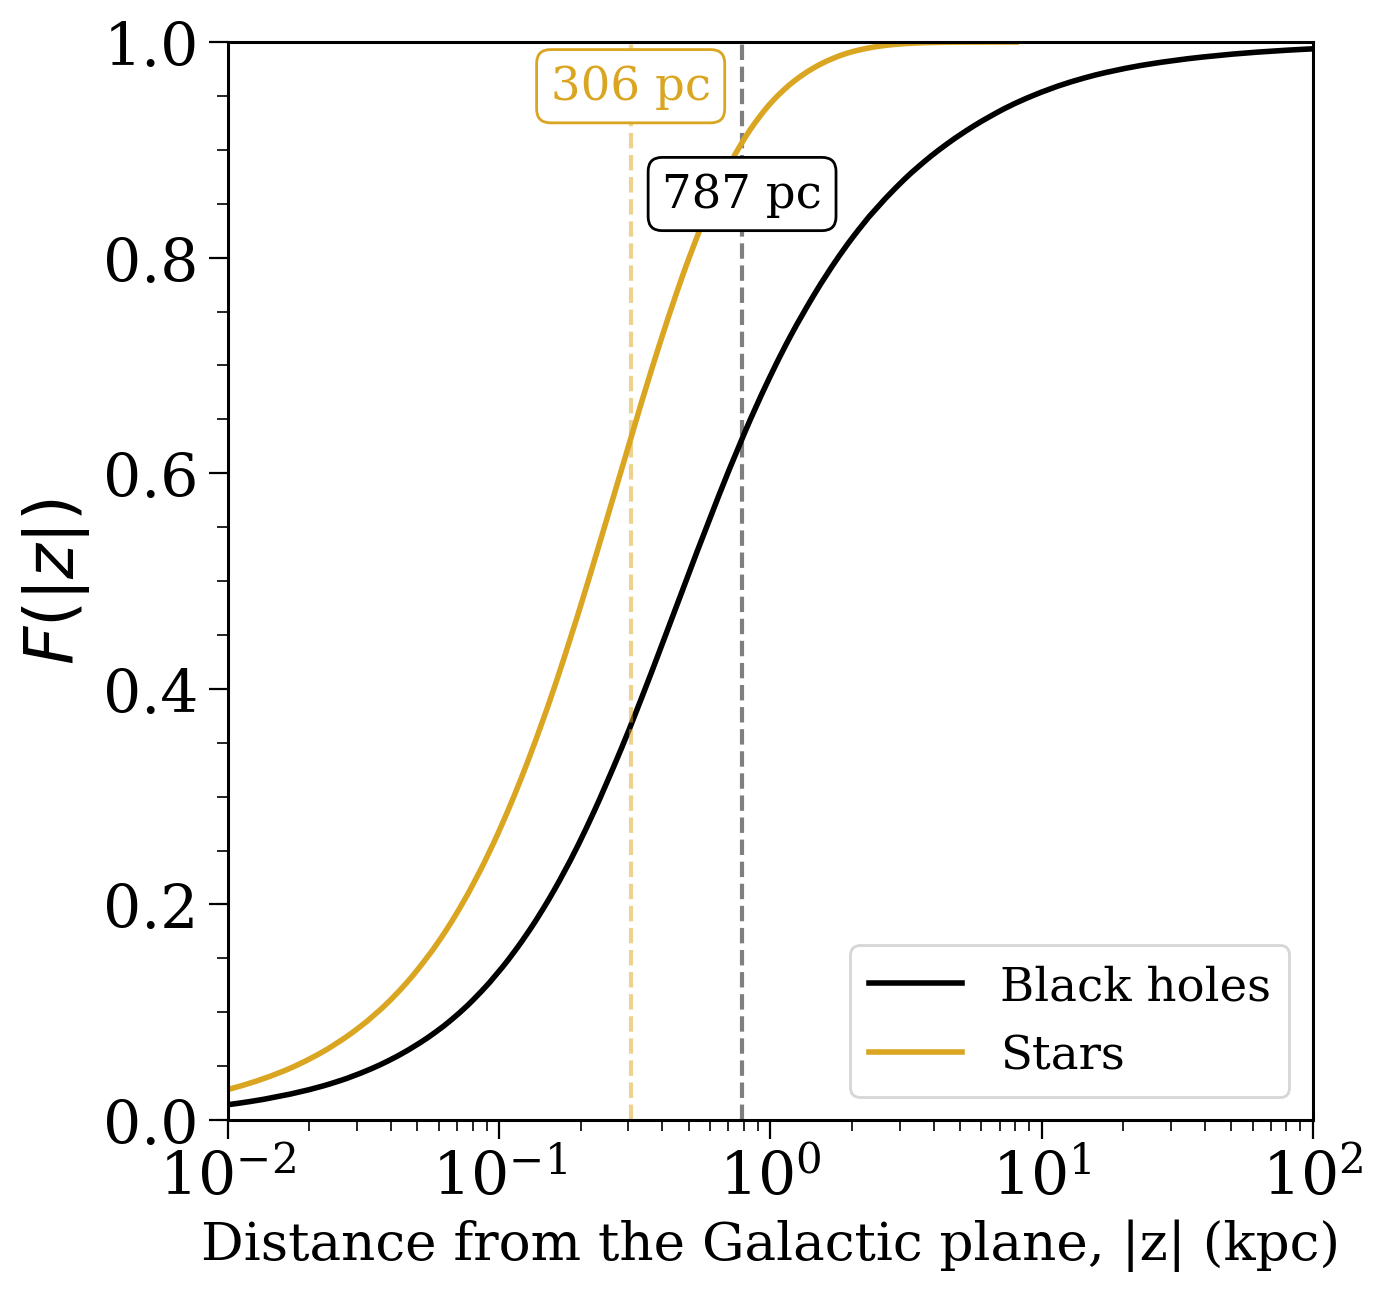

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]], stars.z],#, data["Fiducial"]["pos"]["NS"][:, 2][~data["Fiducial"]["escaped"]["NS"]]],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1.0),
        ylabel=r"$F(|z|)$",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

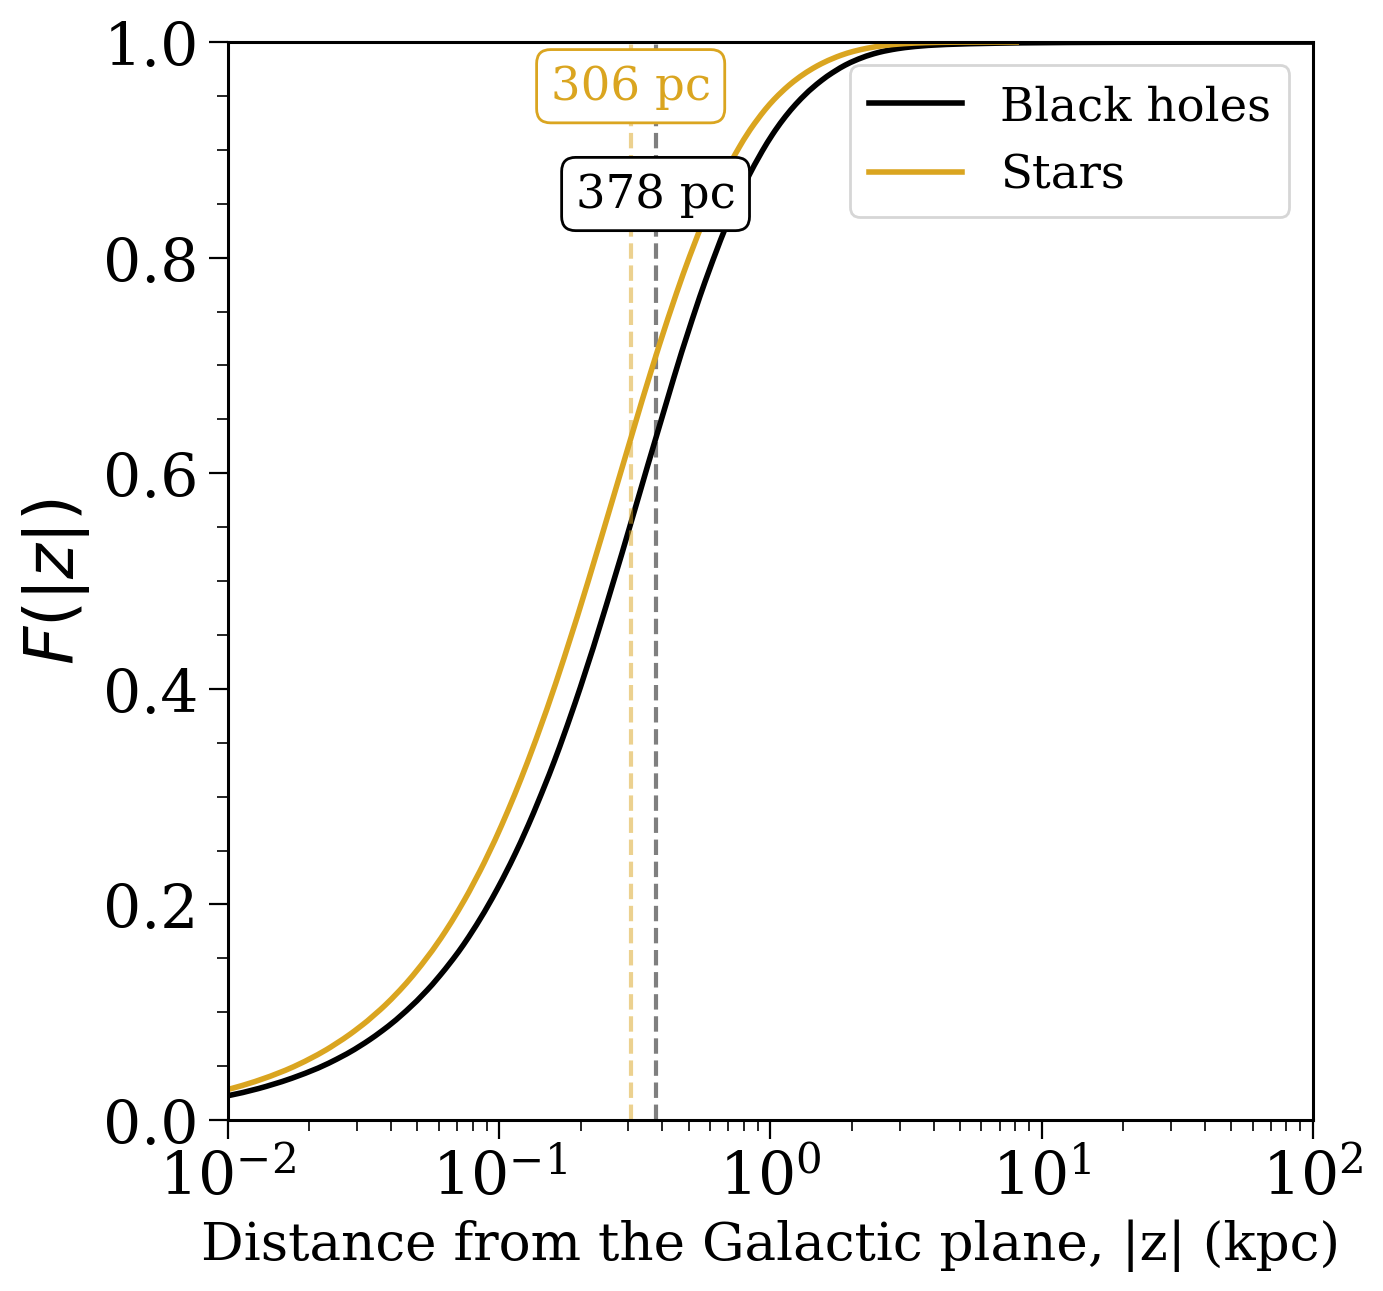

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour, loc in zip(
    [data["BH Flag 0"]["pos"]["BH"][:, 2][~data["BH Flag 0"]["escaped"]["BH"]], stars.z],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1.0),
        ylabel=r"$F(|z|)$",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [12]:
h = np.histogram(rho[~data["Fiducial"]["escaped"]["BH"]], bins=np.linspace(0, 50, 100), density=True)[0]

# adjust for area of each annulus
bin_edges = np.linspace(0, 50, 100)
bin_areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)
h_density = h / bin_areas

print(np.trapezoid(h_density, bin_edges[1:]))

plt.plot(bin_edges[1:], h_density / np.trapezoid(h_density, bin_edges[1:]))

R_range = np.linspace(0, 50, 100)
plt.plot(R_range, np.exp(-R_range / 2.5) / 2.5)

NameError: name 'rho' is not defined

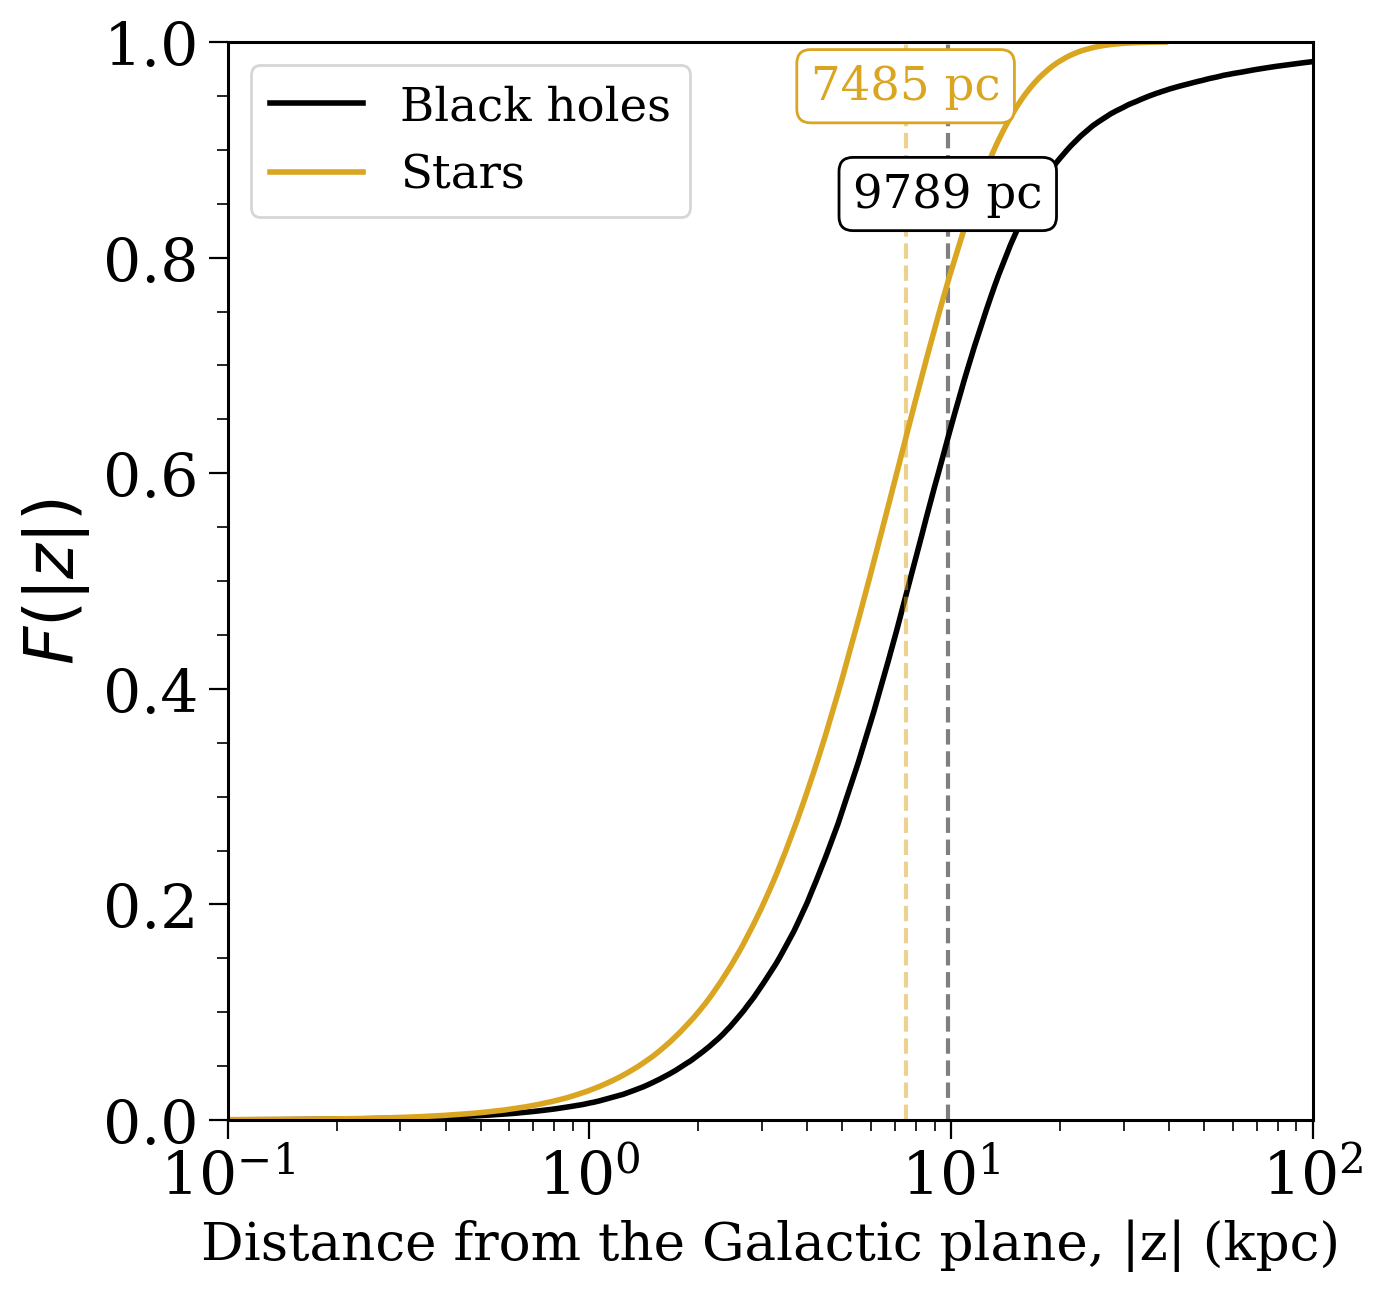

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

rho = np.sum(data["Fiducial"]["pos"]["BH"][:, :2]**2, axis=1)**(0.5)

for z, label, colour, loc in zip(
    [rho[~data["Fiducial"]["escaped"]["BH"]], stars.rho],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-1, 1e2),
        ylim=(0, 1.0),
        ylabel=r"$F(|z|)$",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Without masking escaped ones

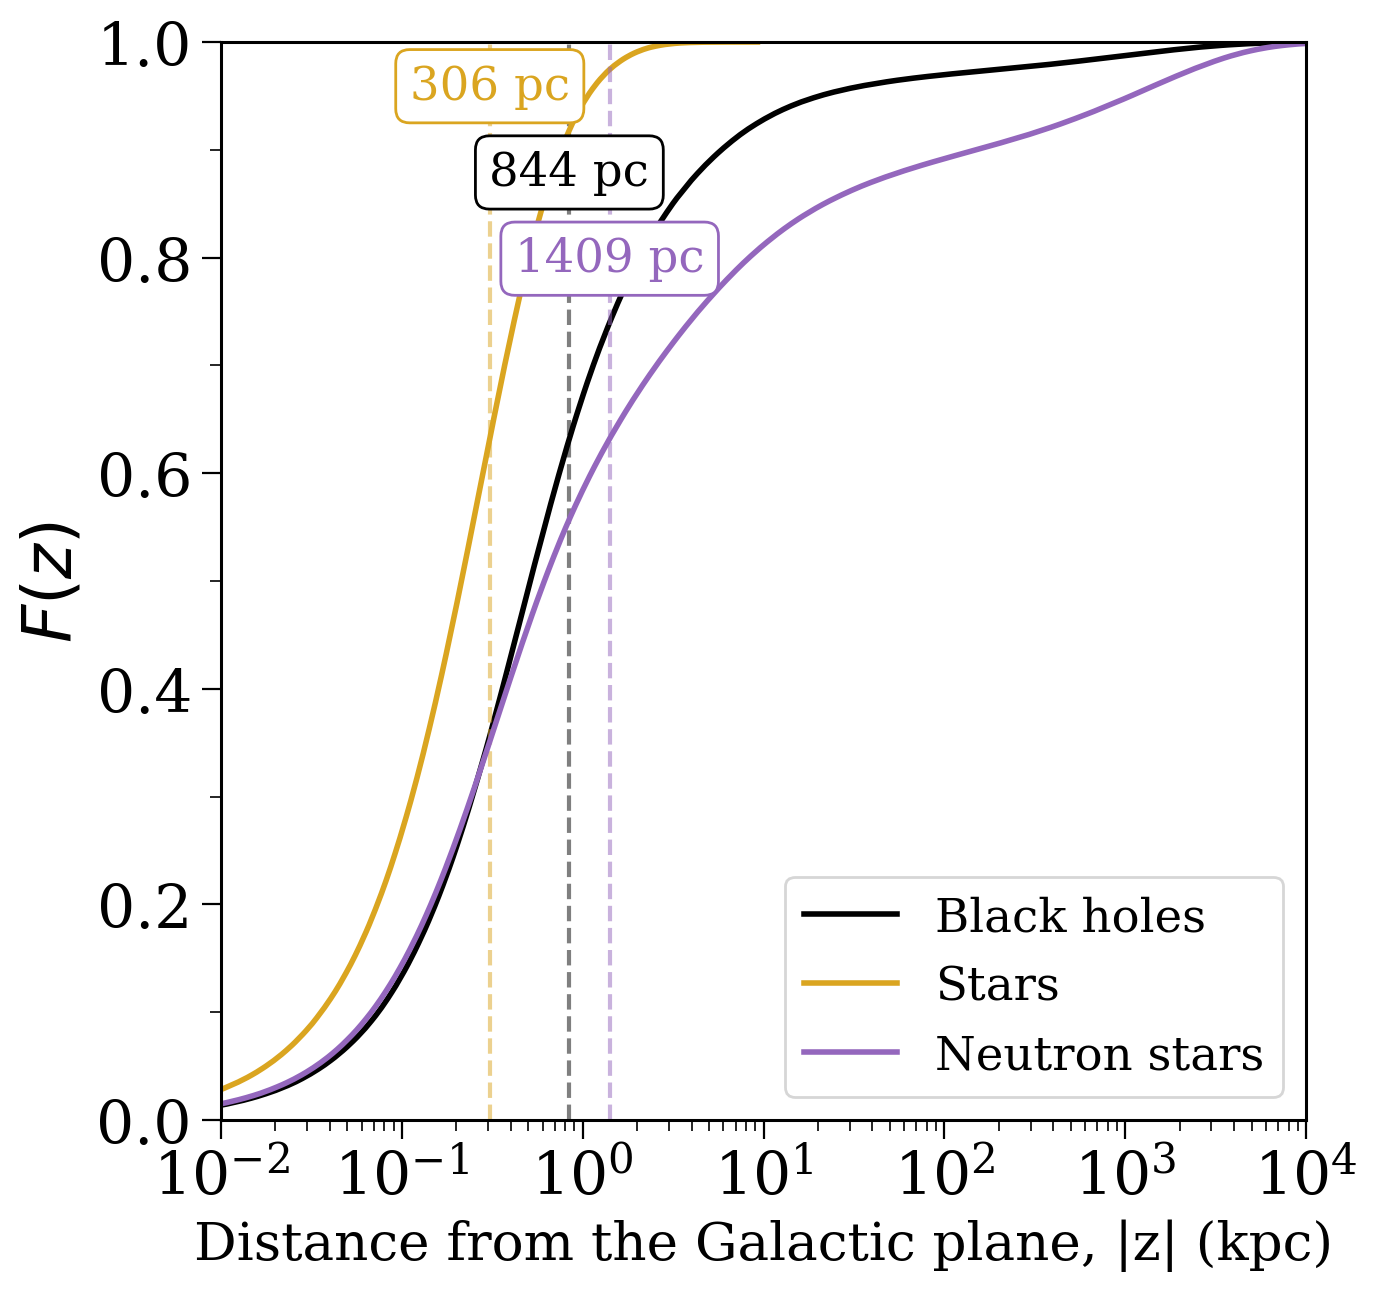

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2], stars.z, data["Fiducial"]["pos"]["NS"][:, 2]],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.08, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e4),
        ylim=(0, 1.0),
        # yscale="log",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Solar neighbourhood

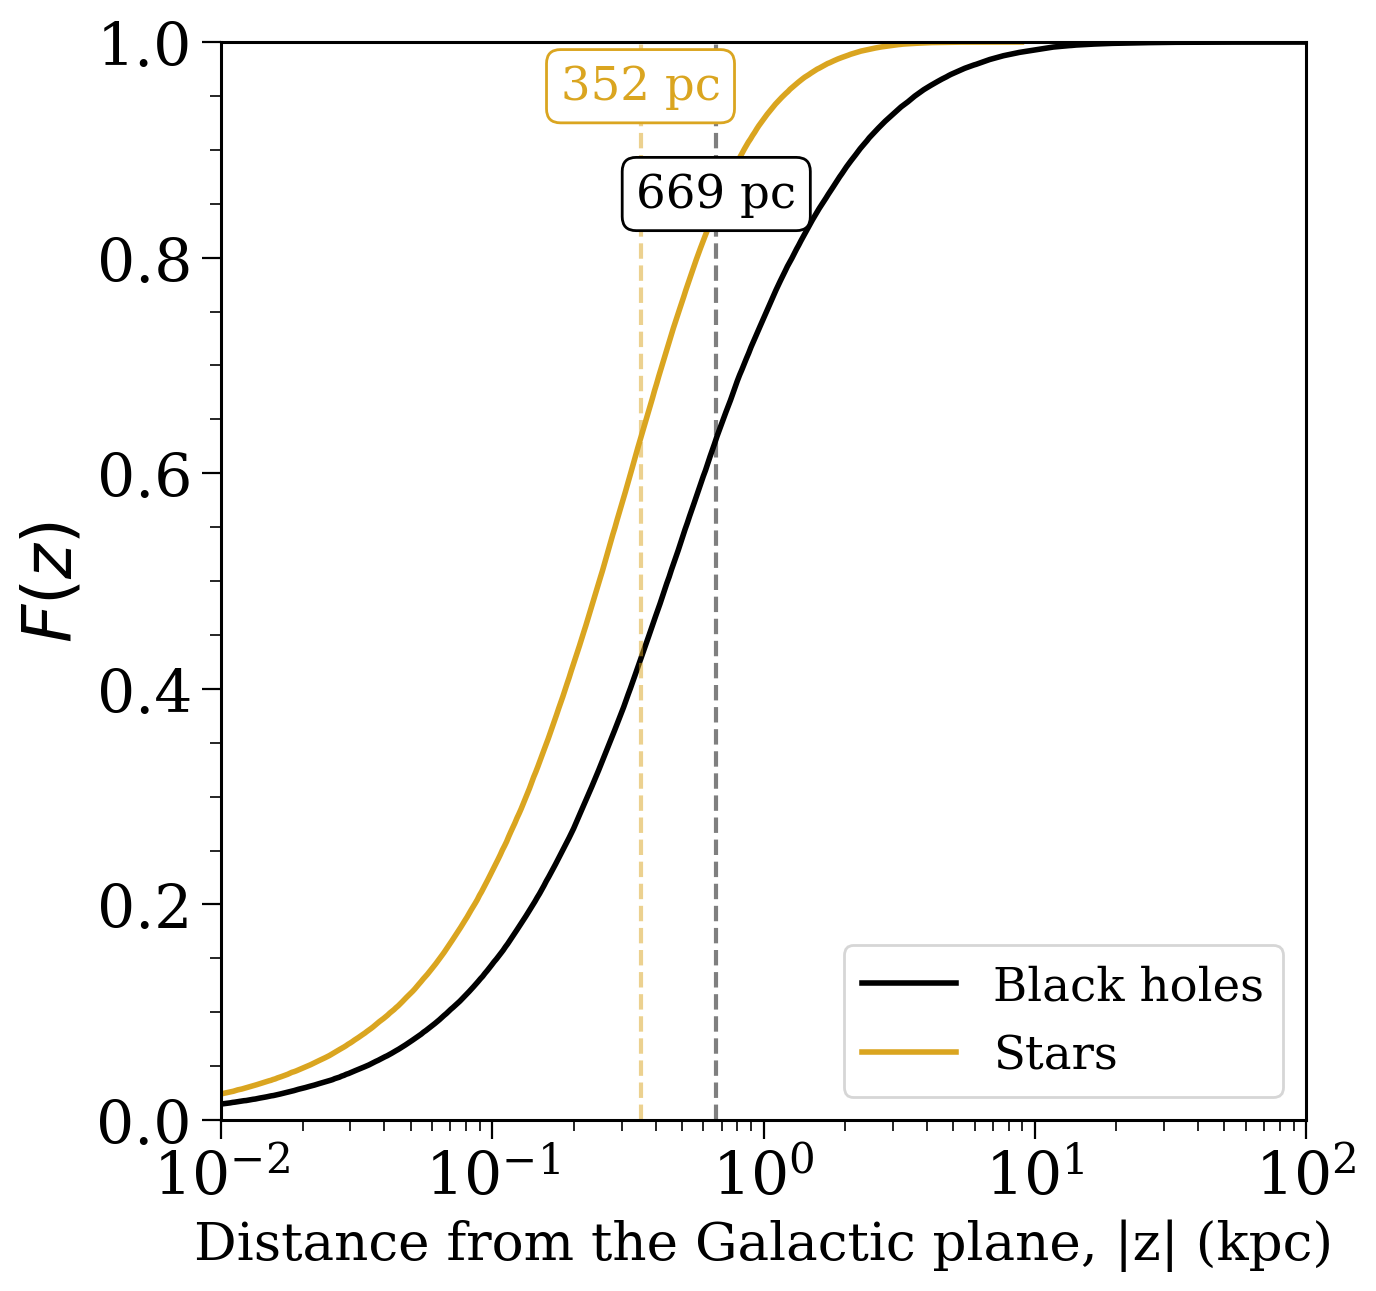

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, R, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]], stars.z],
    [np.sqrt(np.sum(data["Fiducial"]["pos"]["BH"][:, :2]**2, axis=1))[~data["Fiducial"]["escaped"]["BH"]], stars.rho],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1.0),
        # yscale="log",
        scale_height_loc=loc,
        R=R,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

## Compare to Sweeney scale heights

In [ ]:
sweeney = pd.read_csv("~/ceph/underworld/sweeney_data/kicked_remnants_igoshev_young_7.8_DC_integrated_final.csv")

Fitting This work using model: exp
  Optimal parameters: [1.77016672 1.84710834]
  Parameter errors: [12.08975368 17.84942924]
 Estimated scale height: 541.39 pc ± 17.85 pc
Fitting S22: All $R$
(Following this work) using model: exp
  Optimal parameters: [1.68245289 1.69594273]
  Parameter errors: [10.12893121 14.45553688]
 Estimated scale height: 589.69 pc ± 14.46 pc
73571 objects before Rlims
2283 objects in Rlims
Fitting S22: $7.5 < R / {\rm kpc} < 8.5$
(Original method) using model: exp
  Optimal parameters: [1.13609949 1.10546814]
  Parameter errors: [19.89312872 27.84662683]
 Estimated scale height: 904.64 pc ± 27.85 pc


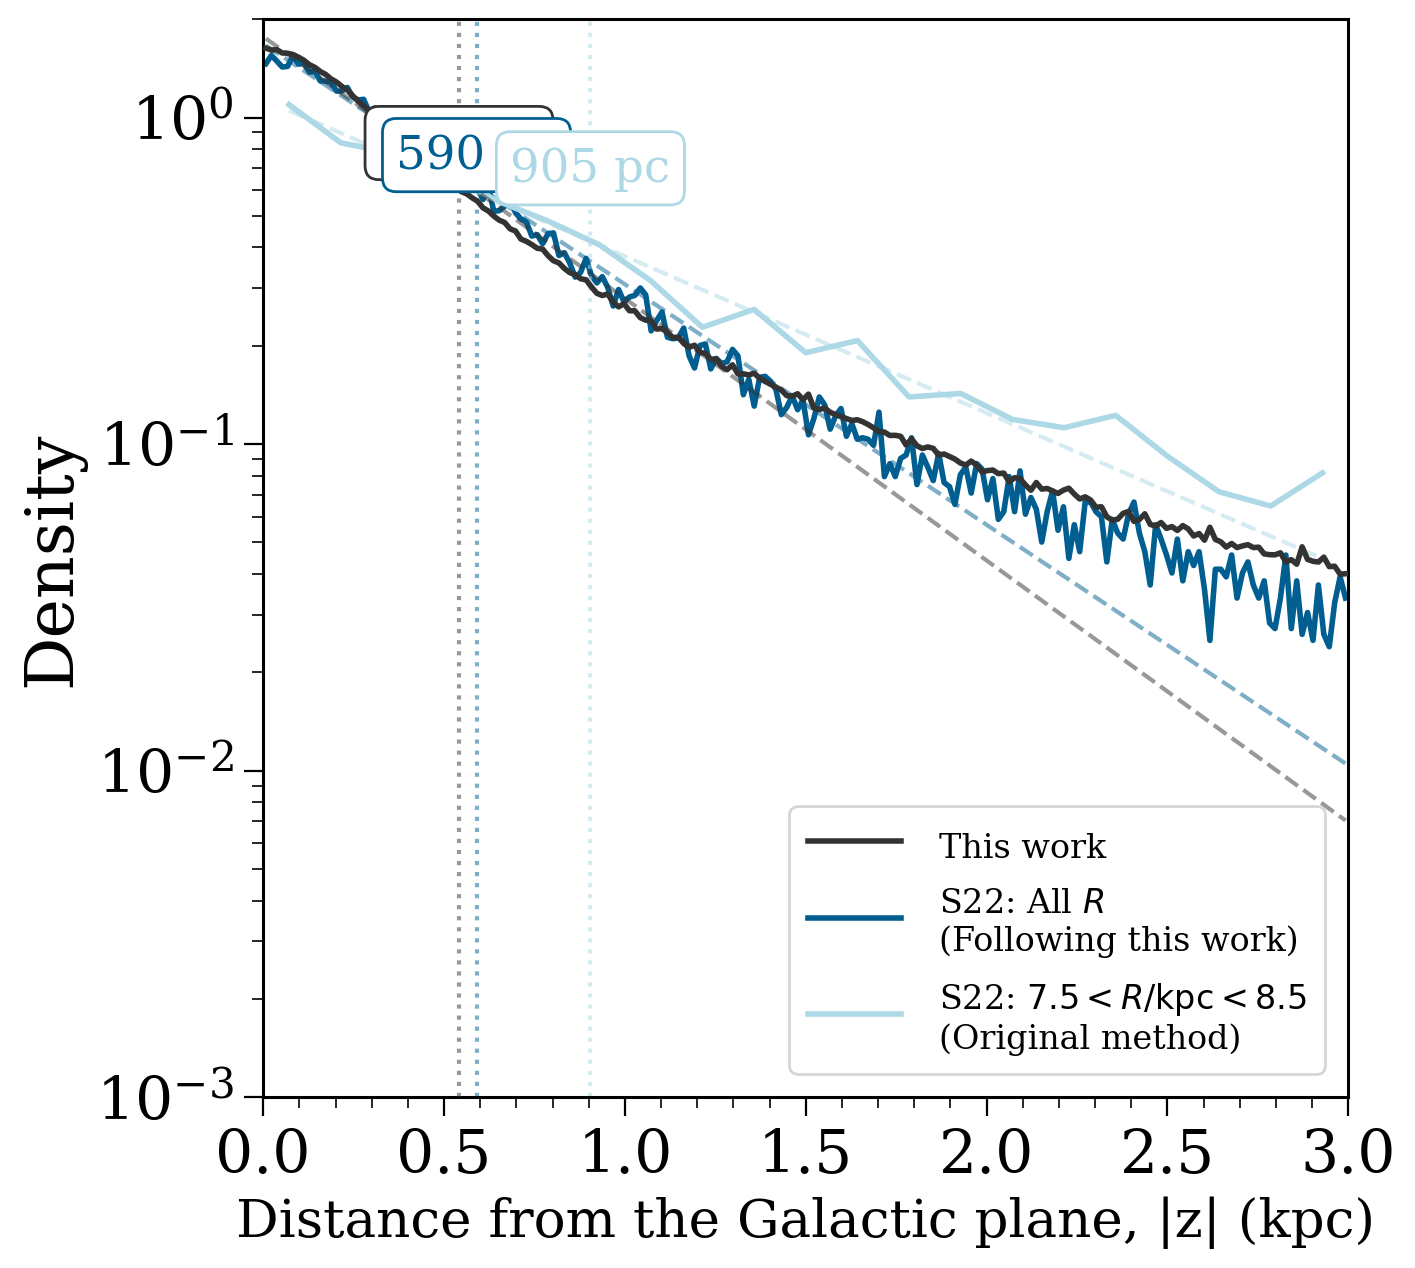

In [ ]:
reload(plotting)

sweeney_bhs = sweeney[(sweeney["rtype"] == "Black Hole") & ~sweeney["will_escape"]]

fig, ax = plt.subplots(figsize=(7, 7))

plotting.estimate_scale_height(
    z=data["Fiducial"]["pos"]["BH"][:, 2],
    plot=True,
    label=r"This work",
    colour="#333",
    fig=fig,
    ax=ax,
    show=False,
    bins=np.linspace(0, 3, 201),
    xlim=(0, 3),
    ylim=(0, 1),
    scale_height_loc=0.98,
    model="exp",
    zorder=100
)

plotting.estimate_scale_height(
    z=sweeney_bhs["pz"].values * u.kpc,
    plot=True,
    label=r"S22: All $R$" + "\n(Following this work)",
    colour="#005e91",
    fig=fig,
    ax=ax,
    show=False,
    bins=np.linspace(0, 3, 201),
    xlim=(0, 3),
    ylim=(0, 1),
    model="exp",
    scale_height_loc=0.98 - 0.08 * 1,
)

plotting.estimate_scale_height(
    z=sweeney_bhs["pz"].values * u.kpc,
    R= sweeney_bhs["R"].values * u.kpc,
    plot=True,
    label=r"S22: $7.5 < R / {\rm kpc} < 8.5$" + "\n(Original method)",
    colour="lightblue",
    fig=fig,
    ax=ax,
    show=False,
    bins="auto",
    yscale="log",
    xlim=(0, 3),
    ylim=(1e-3, 2e0),
    model="exp",
    scale_height_loc=0.98 - 0.08 * 2,
    verbose=True
)

leg = ax.get_legend()
leg.set_loc("lower right")
# leg.set_bbox_to_anchor((1.01, 0.7))
leg.set_title("", prop={'size': 0.6 * fs})
for text in leg.get_texts():
    text.set_fontsize(0.5 * fs)

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_sweeney.pdf", format="pdf", bbox_inches='tight')
plt.show()

73571 objects before Rlims
2283 objects in Rlims


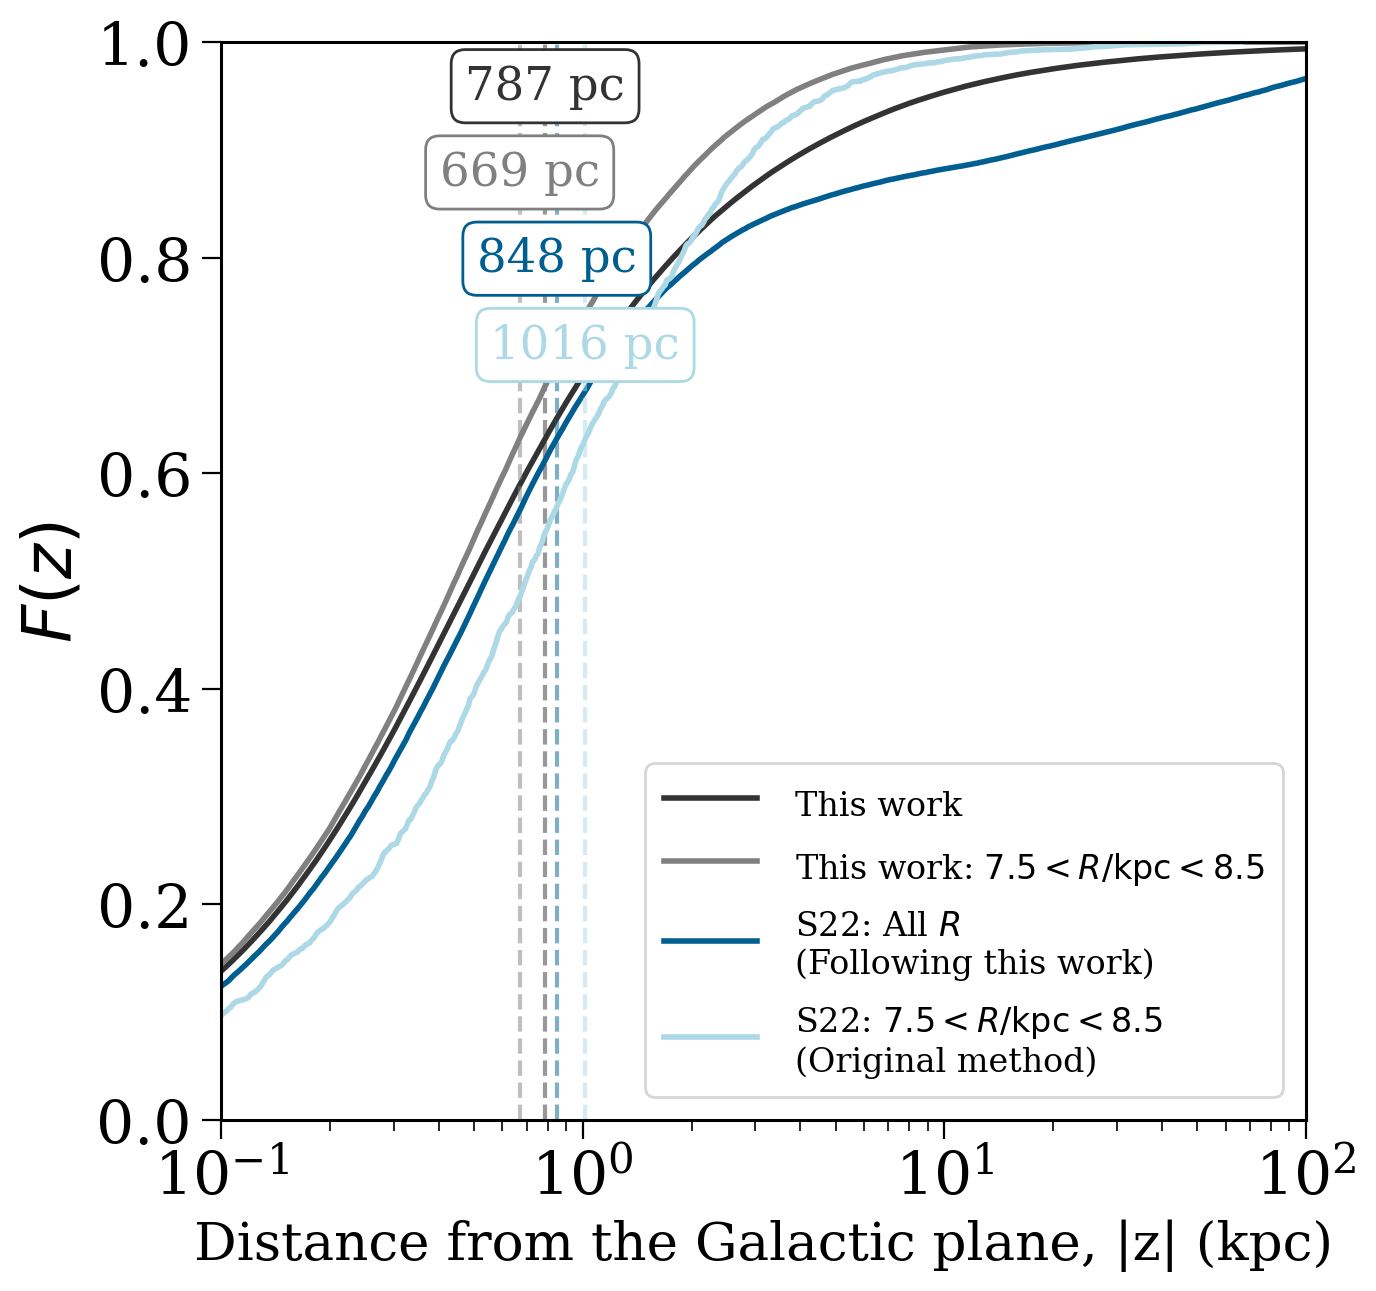

In [ ]:
reload(plotting)

sweeney_bhs = sweeney[(sweeney["rtype"] == "Black Hole") & ~sweeney["will_escape"]]

fig, ax = plt.subplots(figsize=(7, 7))

plotting.estimate_scale_height_cdf(
    z=data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]],
    plot=True,
    label=r"This work",
    colour="#333",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-2, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98,
    zorder=100
)

plotting.estimate_scale_height_cdf(
    z=data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]],
    R=np.linalg.norm(data["Fiducial"]["pos"]["BH"][:, :2], axis=1)[~data["Fiducial"]["escaped"]["BH"]],
    plot=True,
    label=r"This work: $7.5 < R / {\rm kpc} < 8.5$",
    colour="grey",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-2, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98 - 0.08,
    zorder=99
)

plotting.estimate_scale_height_cdf(
    z=sweeney_bhs["pz"].values * u.kpc,
    plot=True,
    label=r"S22: All $R$" + "\n(Following this work)",
    colour="#005e91",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-2, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98 - 0.08 * 2,
)

plotting.estimate_scale_height_cdf(
    z=sweeney_bhs["pz"].values * u.kpc,
    R= sweeney_bhs["R"].values * u.kpc,
    plot=True,
    label=r"S22: $7.5 < R / {\rm kpc} < 8.5$" + "\n(Original method)",
    colour="lightblue",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-1, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98 - 0.08 * 3,
    verbose=True
)

leg = ax.get_legend()
leg.set_loc("lower right")
# leg.set_bbox_to_anchor((1.01, 0.7))
leg.set_title("", prop={'size': 0.6 * fs})
for text in leg.get_texts():
    text.set_fontsize(0.5 * fs)

# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_sweeney.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [ ]:
R_mids

array([ 0.5       ,  0.79591837,  1.09183673,  1.3877551 ,  1.68367347,
        1.97959184,  2.2755102 ,  2.57142857,  2.86734694,  3.16326531,
        3.45918367,  3.75510204,  4.05102041,  4.34693878,  4.64285714,
        4.93877551,  5.23469388,  5.53061224,  5.82653061,  6.12244898,
        6.41836735,  6.71428571,  7.01020408,  7.30612245,  7.60204082,
        7.89795918,  8.19387755,  8.48979592,  8.78571429,  9.08163265,
        9.37755102,  9.67346939,  9.96938776, 10.26530612, 10.56122449,
       10.85714286, 11.15306122, 11.44897959, 11.74489796, 12.04081633,
       12.33673469, 12.63265306, 12.92857143, 13.2244898 , 13.52040816,
       13.81632653, 14.1122449 , 14.40816327, 14.70408163, 15.        ])

In [ ]:
WIDTH = 1

R_mids = np.linspace(WIDTH / 2, 15, 50)

R_lims_bounds = [(R - WIDTH / 2, R + WIDTH / 2) for R in R_mids]

scale_height_at_R = np.array([plotting.estimate_scale_height_cdf(
    z=data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]],
    R=np.linalg.norm(data["Fiducial"]["pos"]["BH"][:, :2], axis=1)[~data["Fiducial"]["escaped"]["BH"]],
    plot=False,
    Rlims=R_lims
)[0] for R_lims in R_lims_bounds])

stars_scale_height_at_R = np.array([plotting.estimate_scale_height_cdf(
    z=stars.z,
    R=stars.rho,
    plot=False,
    Rlims=R_lims
)[0] for R_lims in R_lims_bounds])

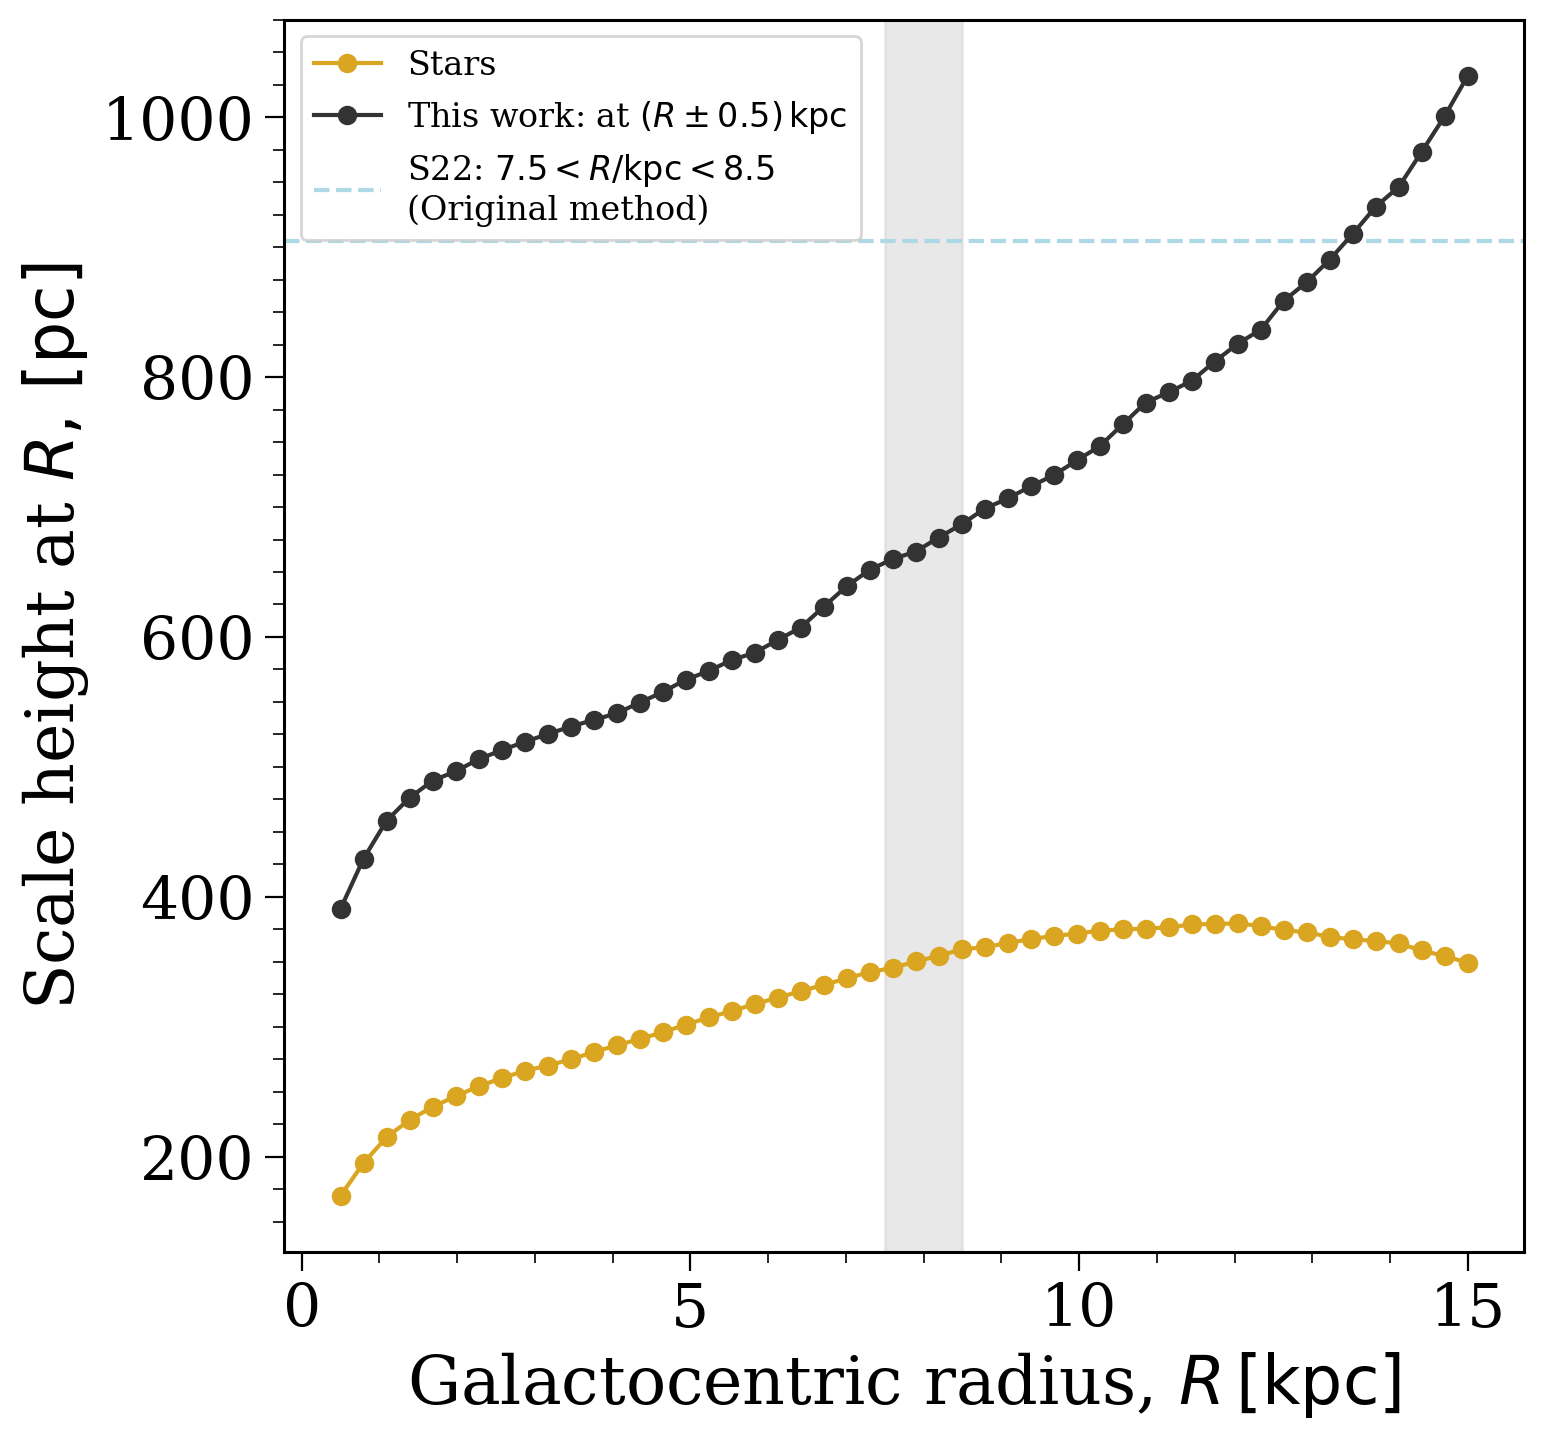

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(R_mids, stars_scale_height_at_R * 1000, marker="o", color='goldenrod', label=r"Stars")
ax.plot(R_mids, scale_height_at_R * 1000, marker="o", color='#333', label=r"This work: at $(R \pm 0.5) \, {\rm kpc}$")
# ax.axhline(778, color='black', linestyle="--", zorder=-1, label="This work: all R")
# ax.axhline(663, color='grey', linestyle="--", zorder=-1, label="This work: 7.5 < R < 8.5")
# ax.axhline(848, color='#005e91', linestyle="--", zorder=-1, label=r"S22: All $R$, two-component model" + "\n(Following this work)")
ax.axhline(905, color='lightblue', linestyle="--", zorder=-1, label=r"S22: $7.5 < R / {\rm kpc} < 8.5$" + "\n(Original method)")

ax.axvspan(7.5, 8.5, color='lightgrey', alpha=0.5, zorder=-2)

ax.set(
    xlabel=r"Galactocentric radius, $R \, [\rm kpc]$",
    ylabel=r"Scale height at $R, \, [\rm pc]$",
)

ax.legend(ncol=1, fontsize=0.5*fs)

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(25))

# plt.savefig("../plots/scale_height_at_R.pdf", format="pdf", bbox_inches='tight')
plt.show()